# Data Cleaning

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel("C:\\Users\\krise\\OneDrive\\Attachments\\Desktop\\portfolio\\Consumer Complaint Intelligence & Risk Analytics Platform\\Data\\Consumer_Complaints.xlsx")

In [3]:
print(df.shape)
df.head()

(62516, 12)


,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [4]:
df.columns

Index(['Complaint ID', 'Submitted via', 'Date submitted', 'Date received',
       'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company response to consumer',
       'Timely response?'],
      dtype='object')

In [5]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("?", "", regex=False)
)

In [6]:
df.columns

Index(['complaint_id', 'submitted_via', 'date_submitted', 'date_received',
       'state', 'product', 'sub-product', 'issue', 'sub-issue',
       'company_public_response', 'company_response_to_consumer',
       'timely_response'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   complaint_id                  62516 non-null  int64         
 1   submitted_via                 62516 non-null  object        
 2   date_submitted                62516 non-null  datetime64[ns]
 3   date_received                 62516 non-null  datetime64[ns]
 4   state                         62516 non-null  object        
 5   product                       62516 non-null  object        
 6   sub-product                   62509 non-null  object        
 7   issue                         62516 non-null  object        
 8   sub-issue                     51658 non-null  object        
 9   company_public_response       60341 non-null  object        
 10  company_response_to_consumer  62516 non-null  object        
 11  timely_response             

In [8]:
df.isnull().sum()

complaint_id                        0
submitted_via                       0
date_submitted                      0
date_received                       0
state                               0
product                             0
sub-product                         7
issue                               0
sub-issue                       10858
company_public_response          2175
company_response_to_consumer        0
timely_response                  1494
dtype: int64

In [9]:
df['sub-product'] = df['sub-product'].fillna('Unknown')

In [10]:
df['sub-issue'] = df['sub-issue'].fillna('Not Specified')

In [11]:
df['company_public_response'] = (
    df['company_public_response']
    .fillna('No Public Response')
)

In [12]:
df['timely_response'] = (
    df['timely_response']
    .fillna('Unknown')
)

In [13]:
df.isnull().sum()

complaint_id                    0
submitted_via                   0
date_submitted                  0
date_received                   0
state                           0
product                         0
sub-product                     0
issue                           0
sub-issue                       0
company_public_response         0
company_response_to_consumer    0
timely_response                 0
dtype: int64

In [14]:
df['date_submitted'] = pd.to_datetime(df['date_submitted'])
df['date_received'] = pd.to_datetime(df['date_received'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   complaint_id                  62516 non-null  int64         
 1   submitted_via                 62516 non-null  object        
 2   date_submitted                62516 non-null  datetime64[ns]
 3   date_received                 62516 non-null  datetime64[ns]
 4   state                         62516 non-null  object        
 5   product                       62516 non-null  object        
 6   sub-product                   62516 non-null  object        
 7   issue                         62516 non-null  object        
 8   sub-issue                     62516 non-null  object        
 9   company_public_response       62516 non-null  object        
 10  company_response_to_consumer  62516 non-null  object        
 11  timely_response             

In [16]:
df['product'].value_counts().head(10)
df['state'].value_counts().head(10)
df['issue'].value_counts().head(10)

issue
Managing an account                                                                 15109
Incorrect information on your report                                                 4931
Problem with a purchase shown on your statement                                      4415
Closing an account                                                                   2953
Trouble during payment process                                                       2827
Opening an account                                                                   2725
Problem with a lender or other company charging your account                         2493
Fraud or scam                                                                        1987
Struggling to pay mortgage                                                           1904
Problem with a credit reporting company's investigation into an existing problem     1876
Name: count, dtype: int64

In [17]:
df['complaint_id'].duplicated().sum()

0

In [18]:
df['timely_response'].value_counts(dropna=False)

timely_response
Yes        58619
No          2403
Unknown     1494
Name: count, dtype: int64

In [19]:
round(
    (df['timely_response'] == 'Yes').sum()
    / len(df) * 100,
    2
)

93.77

In [20]:
df['complaint_month'] = df['date_submitted'].dt.month_name()

In [21]:
df['complaint_year'] = df['date_submitted'].dt.year

In [22]:
df['complaint_quarter'] = df['date_submitted'].dt.quarter

In [23]:
df['resolution_days'] = (
    df['date_received'] - df['date_submitted']
).dt.days

In [24]:
df[['date_submitted',
    'date_received',
    'resolution_days']].head()

,date_submitted,date_received,resolution_days
0,2021-10-24,2021-10-27,3
1,2020-04-24,2020-04-24,0
2,2022-07-27,2022-07-27,0
3,2023-07-10,2023-07-11,1
4,2022-07-27,2022-07-28,1


In [25]:
df['complaint_year'].value_counts()

complaint_year
2022    12953
2021    11149
2023     9131
2020     8942
2018     7872
2019     7075
2017     5394
Name: count, dtype: int64

In [26]:
df['complaint_month'].value_counts()

complaint_month
July         6474
August       5684
May          5608
June         5575
April        5386
March        5335
October      4902
January      4883
September    4765
December     4676
November     4626
February     4602
Name: count, dtype: int64

## EDA

# Complaint Trend by Year

<Axes: xlabel='complaint_year'>

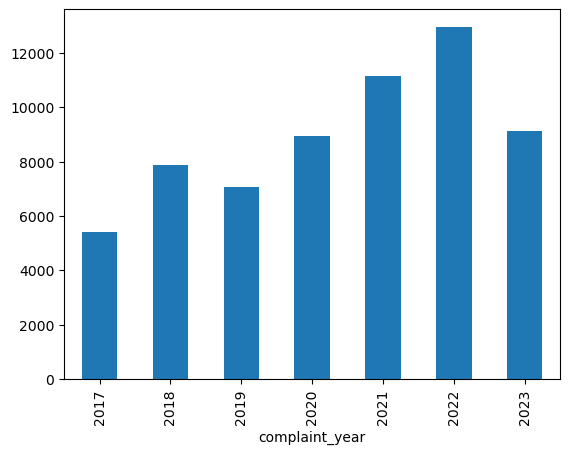

In [27]:
yearly = (
    df['complaint_year']
    .value_counts()
    .sort_index()
)

yearly.plot(kind='bar')

# Complaint Trend by Month

In [28]:
monthly = df['complaint_month'].value_counts()
monthly

complaint_month
July         6474
August       5684
May          5608
June         5575
April        5386
March        5335
October      4902
January      4883
September    4765
December     4676
November     4626
February     4602
Name: count, dtype: int64

<Axes: xlabel='complaint_month'>

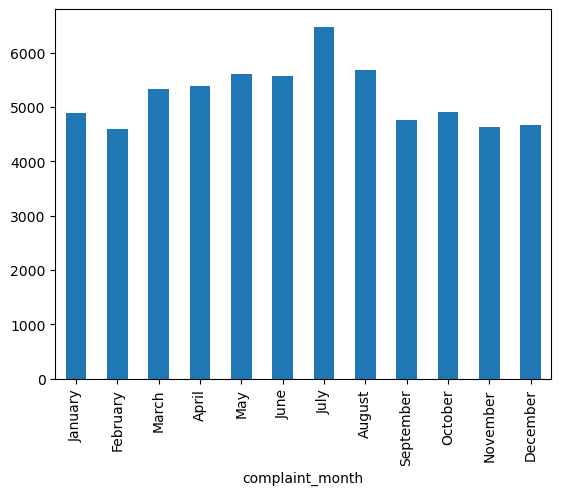

In [29]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]
monthly = (
    df['complaint_month']
    .value_counts()
    .reindex(month_order)
)
monthly.plot(kind='bar')

# Top Products

In [30]:
df['product'].value_counts().head(10)

product
Checking or savings account                                                     24814
Credit card or prepaid card                                                     16197
Credit reporting, credit repair services, or other personal consumer reports     7710
Mortgage                                                                         6601
Money transfer, virtual currency, or money service                               3453
Debt collection                                                                  2736
Vehicle loan or lease                                                             633
Payday loan, title loan, or personal loan                                         333
Student loan                                                                       39
Name: count, dtype: int64

<Axes: ylabel='product'>

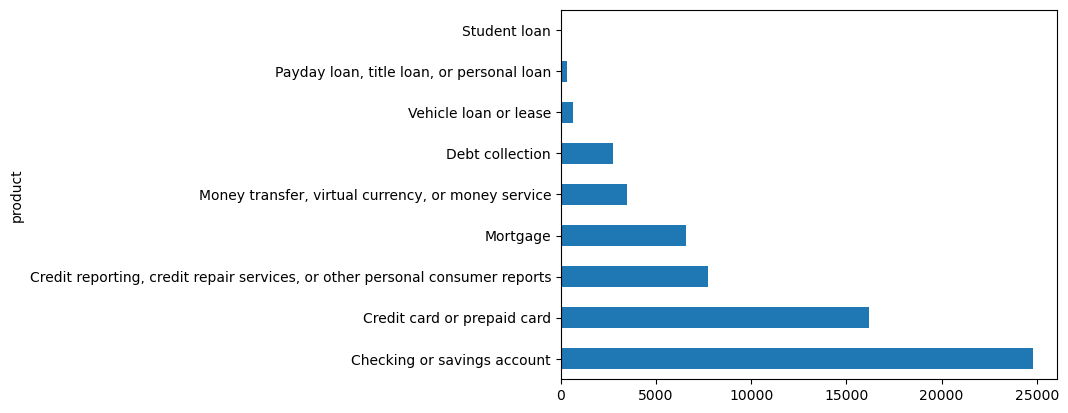

In [31]:
df['product'].value_counts().head(10).plot(kind='barh')

# Top States

In [32]:
df['state'].value_counts().head(10)

state
CA    13709
FL     6488
TX     4686
NY     4442
GA     2921
NJ     2664
IL     2270
MA     2141
MD     1959
VA     1731
Name: count, dtype: int64

<Axes: xlabel='state'>

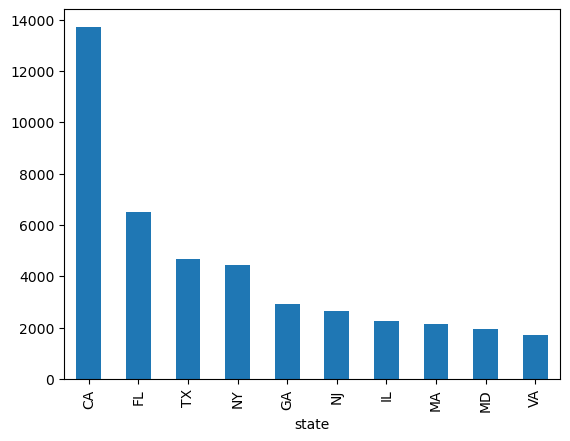

In [33]:
df['state'].value_counts().head(10).plot(kind='bar')

# Top Issues

In [34]:
df['issue'].value_counts().head(15)

issue
Managing an account                                                                 15109
Incorrect information on your report                                                 4931
Problem with a purchase shown on your statement                                      4415
Closing an account                                                                   2953
Trouble during payment process                                                       2827
Opening an account                                                                   2725
Problem with a lender or other company charging your account                         2493
Fraud or scam                                                                        1987
Struggling to pay mortgage                                                           1904
Problem with a credit reporting company's investigation into an existing problem     1876
Getting a credit card                                                                1867
Othe

<Axes: ylabel='issue'>

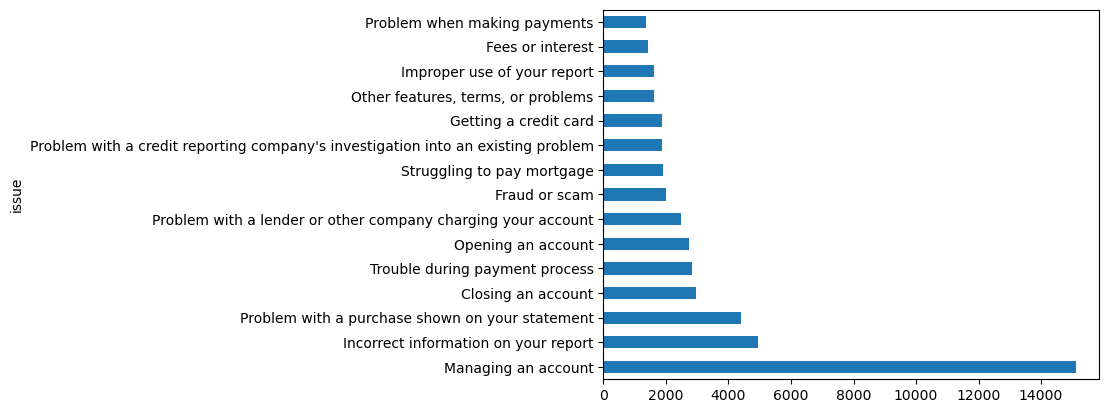

In [35]:
df['issue'].value_counts().head(15).plot(kind='barh')

# Timely Response Analysis

In [36]:
df['timely_response'].value_counts()

timely_response
Yes        58619
No          2403
Unknown     1494
Name: count, dtype: int64

<Axes: ylabel='count'>

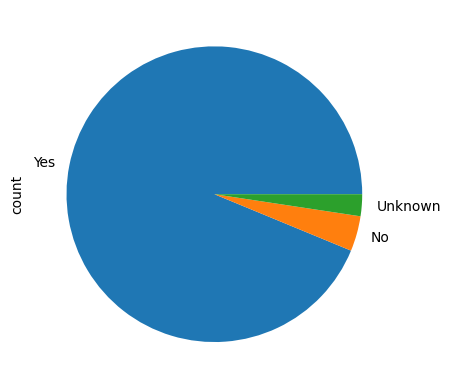

In [37]:
df['timely_response'].value_counts().plot(kind='pie')

# Product vs Timely Response

In [38]:
pd.crosstab(
    df['product'],
    df['timely_response']
)

timely_response,No,Unknown,Yes
product,,,
Checking or savings account,867,710,23237
Credit card or prepaid card,689,412,15096
"Credit reporting, credit repair services, or other personal consumer reports",475,190,7045
Debt collection,173,49,2514
"Money transfer, virtual currency, or money service",140,69,3244
Mortgage,16,46,6539
"Payday loan, title loan, or personal loan",10,2,321
Student loan,0,0,39
Vehicle loan or lease,33,16,584


# State vs Product

In [39]:
pd.crosstab(
    df['state'],
    df['product']
)

product,Checking or savings account,Credit card or prepaid card,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, or personal loan",Student loan,Vehicle loan or lease
state,,,,,,,,,
AK,9,60,11,10,3,17,0,0,0
AL,73,78,49,15,17,27,1,1,8
AR,118,57,25,18,15,28,2,0,3
AZ,633,440,126,48,88,165,7,1,8
CA,5335,4271,1530,417,828,1199,55,8,66
CO,160,219,64,24,19,80,1,0,9
CT,551,208,75,42,55,147,9,1,9
DC,155,76,32,15,18,52,2,0,3
DE,73,107,27,5,7,40,2,0,7
